# Langraph Fundamentals

In [ ]:
b

In [ ]:
# Langchains create agent
    # middleware
    # Runtime context


# Cover human in the loop

## State




## Nodes



## Edges



## 7) LangGraph: Workflows

LangGraph builds **stateful** graphs for control flow (branching, loops, retries).  
We'll create a tiny graph with one node that calls the model, and a conditional router.


In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AnyMessage, AIMessage
from pydantic import BaseModel, Field
from prompts import INTENT_DETECTION_TEMPLATE

#state
class GraphState(TypedDict):
    messages: List[AnyMessage]


In [ ]:
#Define the graph nodes

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


def intent_node(state: GraphState) -> GraphState:

    class Intent(BaseModel):
        intent: str = Field(..., description="User intent. One of:  TIMEOFF, GREETING, OTHER")

    structured_llm = llm.with_structured_output(Intent)
    prompt = ChatPromptTemplate.from_messages([('system', INTENT_DETECTION_TEMPLATE)] + state['messages'])
    chain = prompt | structured_llm
    response = chain.invoke(state)

    return {"messages": state["messages"] + [AIMessage(content= response.intent)]}

def time_off_node(state: GraphState) -> GraphState:
    ai_msg = AIMessage(content="Sure, I can help you with your time off request")
    return {"messages": state["messages"] + [ai_msg]}

def greeting_node(state: GraphState) -> GraphState:
    ai_msg = AIMessage(content="Hello, how can I help you today?")
    return {"messages": state["messages"] + [ai_msg]}

def other_node(state: GraphState) -> GraphState:
    ai_msg = AIMessage(content="I'm sorry, I don't understand. Please try again.")
    return {"messages": state["messages"] + [ai_msg]} 

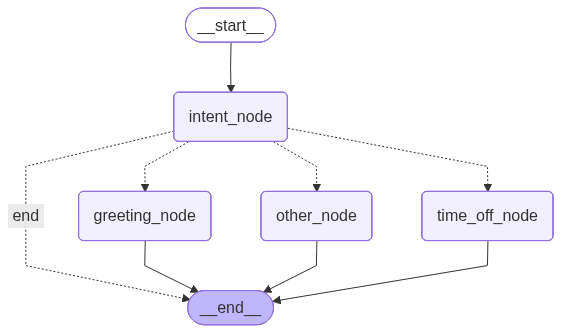

In [ ]:
  

# Initialize the graph
graph = StateGraph(GraphState)
graph.add_node("intent_node", intent_node)
graph.add_node("time_off_node", time_off_node)
graph.add_node("greeting_node", greeting_node)
graph.add_node("other_node", other_node)

# Simple router: route to the correct branch based on the intent
def router(state: GraphState) -> str:
    last = state["messages"][-1]
    text = getattr(last, "content", "").lower()

    
    if text == "timeoff":
        return "time_off_node"
    elif text == "greeting":
        return "greeting_node"
    elif text == "other":
        return "other_node"
    else:
        return 'end'

# Add edges
graph.add_edge(START, "intent_node")
graph.add_conditional_edges("intent_node", router, {"end": END, "time_off_node": "time_off_node", "greeting_node": "greeting_node", "other_node": "other_node"})


workflow = graph.compile()

workflow

In [ ]:
user_query = "Hello"
# user_query = "I would like to apply for time off"
# user_query = "What is the weatehr like in SF"

response = workflow.invoke({"messages": [HumanMessage(content= user_query)]})

response

{'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}),
  AIMessage(content='GREETING', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello, how can I help you today?', additional_kwargs={}, response_metadata={})]}

In [ ]:
response["messages"][-1].content

'Hello, how can I help you today?'

## 8) LangGraph: Agents (Prebuilt ReAct)

LangGraph includes prebuilt agent constructors like `create_react_agent`.  
We'll give the agent a couple of trivial tools and see how it plans + acts.


Langchain's create agent!


In [ ]:
# Langchains create agent
    # middleware
    # Runtime context

In [ ]:
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import AnyMessage, AIMessage, ToolMessage

@tool
def to_celsius(f: float) -> float:
    """Convert Fahrenheit to Celsius"""
    return (f - 32) * 5/9

@tool
def to_fahrenheit(c: float) -> float:
    """Convert Celsius to Fahrenheit"""
    return (c * 9/5) + 32

agent = create_react_agent(llm, tools=[to_celsius, to_fahrenheit])

# The agent returns a stream of steps; we can iterate until it yields a final answer.
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

# Single turn
events = agent.stream(
    {"messages": [HumanMessage(content="It's 77F outside. What's that in Celsius, rounded to 1 decimal?")]},
    config={"configurable": {"thread_id": "demo"}, "checkpoint": memory},
    stream_mode="messages"
)

for node, msgs in events.items():
    for m in msgs:
        if isinstance(m, AIMessageChunk):
            print(m.content, end="", flush=True)   # token-by-token
        elif isinstance(m, ToolMessage):
            print(f"\n[tool:{node}] {m.content}")   



# for event in events:
#     print(event.items())
#     kind, payload = next(iter(event.items()))
#     print(kind, payload)



AttributeError: 'generator' object has no attribute 'items'